---
title: 'Solutions: Review of Linear Unsupervised Learning'
author: Mark Fuge
format:
    html:
        code-fold: true
        code-summary: "Show Solution Code"
---

These are worked solutions to the exercises at the end of the chapter *Review of Linear Unsupervised Learning*.

In [1]:
import io

import matplotlib.pyplot as plt
import numpy as np
import requests
from matplotlib.colors import TwoSlopeNorm
from sklearn import decomposition
from sklearn.decomposition import NMF, DictionaryLearning, SparsePCA

# --- The chapter's data: 1528 airfoils as 192 x 2 coordinates, centered, first 80% for fitting ---
url = "https://github.com/IDEALLab/ML4ME_Textbook/raw/main/part1/airfoil_interp_uniform.npy"
response = requests.get(url)
response.raise_for_status()
X_airfoils = np.load(io.BytesIO(response.content))
coordinate_means = X_airfoils.mean(axis=(0, 1))
X_airfoils = X_airfoils - coordinate_means


def make_matrix(X): return np.reshape(X, (X.shape[0], -1))
def make_airfoil(X): return X.reshape((-1, 2))


N = X_airfoils.shape[0]
split = int(N * 0.8)
X_train = make_matrix(X_airfoils[:split])
X_test = make_matrix(X_airfoils[split:])
data = X_train


def reorder_indices(components):
    return np.hstack([components[:, 0:-1:2], components[:, 1:-1:2]])


def reconstruct_pca(X, k):
    """Map the rows of X to their first k PCA latent coordinates and back to airfoil coordinates."""
    Z = estimator.transform(X)[:, :k]
    return Z @ estimator.components_[:k] + estimator.mean_


def rms_error(X, X_hat):
    """Root-mean-square error over the 384 coordinates of each airfoil (one number per row)."""
    return np.sqrt(np.mean((X - X_hat) ** 2, axis=1))


def plot_airfoil(x, ax=None, **kwargs):
    """Draw one flattened airfoil (length-384 vector) on the given axes."""
    xy = make_airfoil(x)
    ax = ax if ax is not None else plt.gca()
    ax.plot(xy[:, 0], xy[:, 1], **kwargs)
    ax.set_aspect('equal')


# --- The chapter's four models, with the chapter's settings and seeds ---
estimator = decomposition.PCA(n_components=20, svd_solver='full')
Z_pca = estimator.fit_transform(data)
components_ = estimator.components_

spca = SparsePCA(n_components=12, alpha=0.01, random_state=42)
spca.fit(data)
W_sp = spca.components_
Z_sp = spca.transform(data)

shift = data.min()
Xpos = data - shift + 1e-6
nmf = NMF(n_components=14, init='nndsvda', random_state=42, max_iter=5000, alpha_W=0.001, l1_ratio=0.001)
Z_nmf = nmf.fit_transform(Xpos)
W_nmf = nmf.components_

# Dictionary Learning with the chapter's settings, including the chapter's cap of 30 iterations at tol 1e-4 (about half a minute)
DL = DictionaryLearning(n_components=10, alpha=0.1, random_state=42, max_iter=30, tol=1e-4)
Z_dl = DL.fit_transform(data)
W_dl = DL.components_

### Exercise 1: Which method has which property?

In [2]:
fitted = {"PCA": (components_, Z_pca), "Sparse PCA": (W_sp, Z_sp),
          "Dictionary Learning": (W_dl, Z_dl), "NMF": (W_nmf, Z_nmf)}
for name, (W, Z) in fitted.items():
    gram = W @ W.T
    off_diagonal = np.abs(gram - np.diag(np.diag(gram)))
    print(f"{name:20s} largest |off-diagonal of W W^T| {off_diagonal.max():8.2g}   "
          f"exact zeros: W {np.mean(W == 0):5.1%}, Z {np.mean(Z == 0):5.1%}   "
          f"negative entries: W {np.mean(W < 0):5.1%}, Z {np.mean(Z < 0):5.1%}")

# Dictionary Learning: unit-length atoms, but how close to parallel are they?
atoms = W_dl / np.linalg.norm(W_dl, axis=1, keepdims=True)
print(f"\nDictionary Learning: atom norms {np.round(np.linalg.norm(W_dl, axis=1), 3)}")
print(f"Dictionary Learning: median |cosine| between two different atoms {np.median(np.abs(atoms @ atoms.T)[np.triu_indices(len(atoms), 1)]):.3f}")


def cosine(a, b):
    return abs(a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))


pca_5 = decomposition.PCA(n_components=5, svd_solver='full').fit(data)
nmf_5 = NMF(n_components=5, init='nndsvda', random_state=42, max_iter=5000, alpha_W=0.001, l1_ratio=0.001).fit(Xpos)
print(f"\n|cosine| between the first component of the 5- and the 20-component PCA: {cosine(pca_5.components_[0], components_[0]):.6f}")
print(f"|cosine| between the first component of the 5- and the 14-component NMF: {cosine(nmf_5.components_[0], W_nmf[0]):.3f}")

PCA                  largest |off-diagonal of W W^T|  6.4e-16   exact zeros: W  0.0%, Z  0.0%   negative entries: W 47.9%, Z 50.0%
Sparse PCA           largest |off-diagonal of W W^T|     0.45   exact zeros: W 75.5%, Z  0.0%   negative entries: W  4.8%, Z 51.3%
Dictionary Learning  largest |off-diagonal of W W^T|     0.99   exact zeros: W  0.0%, Z 56.9%   negative entries: W 51.6%, Z  5.5%
NMF                  largest |off-diagonal of W W^T|       42   exact zeros: W  4.4%, Z  1.6%   negative entries: W  0.0%, Z  0.0%

Dictionary Learning: atom norms [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Dictionary Learning: median |cosine| between two different atoms 0.947

|cosine| between the first component of the 5- and the 20-component PCA: 1.000000
|cosine| between the first component of the 5- and the 14-component NMF: 0.945


| Property | PCA | Sparse PCA | Dictionary Learning | NMF |
|---|---|---|---|---|
| Components mutually orthogonal | yes: constraint $W W^\top = I$ | no | no | no |
| Many entries of $W$ exactly zero | no | yes: penalty $\alpha \lVert W \rVert_1$ | no | a few (4%) |
| Many entries of $Z$ exactly zero | no | no | yes: penalty $\alpha \lVert Z \rVert_1$ | a few (2%) |
| No negative entries in $W$ or $Z$ | no | no | no | yes: constraints $W \ge 0$, $Z \ge 0$ |
| First component unchanged with fewer components | yes | no | no | no |

**(a)** The L1 penalty gives exact zeros because its gradient does not shrink as an entry approaches zero, so small entries are pushed all the way to zero. A squared penalty pulls less as an entry gets smaller, so it only shrinks entries. Sparse PCA puts the L1 penalty on $W$, so each component covers only part of the profile. Dictionary Learning puts it on $Z$, so each airfoil uses only a few atoms. NMF's constraints rule out negative entries. Only PCA constrains the components to be orthogonal.

**(b)** The printout agrees with the table. Three points to note:

- NMF has a few exact zeros (4% of $W$, 2% of $Z$) even though its L1 penalty is tiny. Entries whose unconstrained optimum would be negative are clipped to zero.
- The NMF components are far from orthogonal (largest off-diagonal of $W W^\top$: 42). Two non-negative vectors are orthogonal only if they are never nonzero at the same coordinate.
- The Dictionary Learning atoms have unit length but are nearly parallel (median absolute cosine 0.95). The objective does not ask the atoms to differ, and the L1 penalty on $Z$ favors describing each airfoil with a single atom. The atoms therefore end up as slightly different whole airfoils, which matches the atom plots in the chapter.

**(c)** The first PCA component does not change (absolute cosine 1.000000); the first NMF component does (0.945). PCA with $k$ components returns the top $k$ eigenvectors of the covariance matrix, so asking for fewer components only shortens the list. The other three methods fit all components together, so changing their number changes every component. NMF also does not order its components by importance, so its first component has no special meaning.

### Exercise 2: PCA by hand

In [3]:
mean_airfoil = X_train.mean(axis=0)
U, S, Vt = np.linalg.svd(X_train - mean_airfoil, full_matrices=False)

agreement = np.sum(Vt[:20] * components_, axis=1)      # dot products of unit vectors: +1 or -1 if they agree
print("dot product of each hand-made component with sklearn's:", np.round(agreement, 6))

ratio_by_hand = S**2 / np.sum(S**2)
print("explained variance ratio, first 5, by hand:", np.round(ratio_by_hand[:5], 4))
print("explained variance ratio, first 5, sklearn:", np.round(estimator.explained_variance_ratio_[:5], 4))
print("largest difference over 20 components:", np.abs(ratio_by_hand[:20] - estimator.explained_variance_ratio_).max())

dot product of each hand-made component with sklearn's: [-1. -1.  1.  1. -1.  1.  1.  1. -1. -1. -1. -1.  1.  1.  1. -1. -1.  1.
  1. -1.]
explained variance ratio, first 5, by hand: [0.4866 0.4098 0.0342 0.0271 0.0159]
explained variance ratio, first 5, sklearn: [0.4866 0.4098 0.0342 0.0271 0.0159]
largest difference over 20 components: 2.220446049250313e-16


**(a)** All dot products are $+1$ or $-1$, so the components agree up to sign; 10 of the 20 signs differ. If $v$ is a singular vector, so is $-v$. Flipping $v$ also flips the matching column of $Z$, so $Z W$ does not change. `sklearn` applies its own sign convention and `np.linalg.svd` does not. The sign of a component therefore means nothing on its own, only together with the sign of its latent coordinate.

**(b)** The ratios agree to $2 \times 10^{-16}$. The latent coordinates along component $j$ are $X v_j = s_j u_j$, where $u_j$ has unit length, so their variance is $s_j^2 / n$. The ratio $s_j^2 / \sum_i s_i^2$ does not depend on $n$. Variance is a mean of squares, so it scales with $s_j^2$.

### Exercise 3: Cleaning up a noisy scan

noise level 0.001: best k 33, error against the truth there 0.00033, at k = 100 0.00051
noise level 0.003: best k 18, error against the truth there 0.00076, at k = 100 0.00153
noise level 0.01: best k 9, error against the truth there 0.00188, at k = 100 0.00510


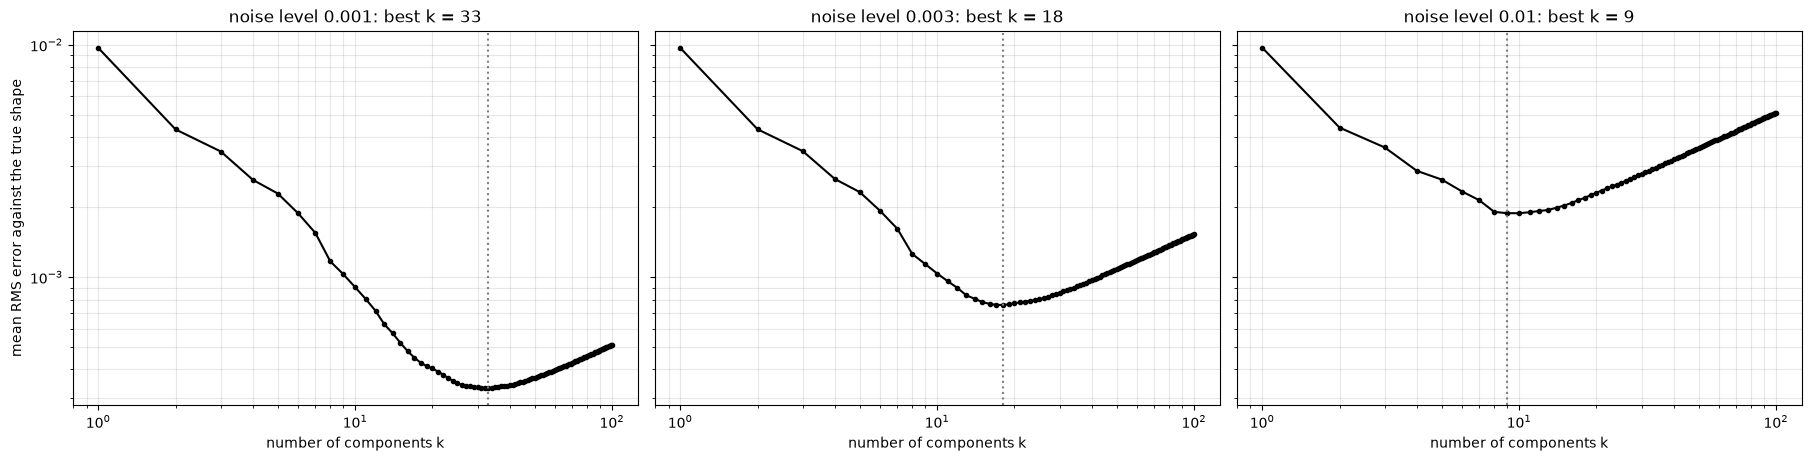


noise level 0.003: k chosen by cross-validation over the points of each scan: 18
error against the truth at that k: 0.00076 (best possible 0.00076)


In [4]:
pca_100 = decomposition.PCA(n_components=100, svd_solver='full').fit(X_train)
ks = np.arange(1, 101)


def project(X, k):
    """Project rows of X onto the first k components of pca_100 and back."""
    Z = pca_100.transform(X)[:, :k]
    return Z @ pca_100.components_[:k] + pca_100.mean_


def scan_errors(noise_level, seed=0):
    """Mean RMS error of the projected scans against the scan and against the true shape, for k = 1..100."""
    rng = np.random.default_rng(seed)
    X_scanned = X_test + noise_level * rng.standard_normal(X_test.shape)
    vs_scan = np.array([rms_error(X_scanned, project(X_scanned, k)).mean() for k in ks])
    vs_true = np.array([rms_error(X_test, project(X_scanned, k)).mean() for k in ks])
    return X_scanned, vs_scan, vs_true


fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True, layout='constrained')
for ax, noise_level in zip(axes, [0.001, 0.003, 0.01]):
    _, vs_scan, vs_true = scan_errors(noise_level)
    best = ks[np.argmin(vs_true)]
    print(f"noise level {noise_level}: best k {best}, error against the truth there {vs_true.min():.5f}, "
          f"at k = 100 {vs_true[-1]:.5f}")
    ax.loglog(ks, vs_true, '.-', color='k')
    ax.axvline(best, color='gray', linestyle=':')
    ax.set_title(f"noise level {noise_level}: best k = {best}")
    ax.set_xlabel("number of components k")
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel("mean RMS error against the true shape")
plt.show()

# Choosing k from the scans alone: hide every fifth point of each scan, fit the latent coordinates
# on the other points, and measure how well they predict the hidden points.
X_scanned, _, vs_true_003 = scan_errors(0.003)
point_folds = np.arange(192) % 5
cv_error = []
for k in ks:
    W = pca_100.components_[:k]
    squared_errors = []
    for fold in range(5):
        kept = np.flatnonzero(point_folds != fold)
        held = np.flatnonzero(point_folds == fold)
        kept_coords = np.sort(np.concatenate([2 * kept, 2 * kept + 1]))
        held_coords = np.sort(np.concatenate([2 * held, 2 * held + 1]))
        Z_fit = np.linalg.lstsq(W[:, kept_coords].T, (X_scanned - pca_100.mean_)[:, kept_coords].T, rcond=None)[0].T
        prediction = Z_fit @ W[:, held_coords] + pca_100.mean_[held_coords]
        squared_errors.append(np.mean((prediction - X_scanned[:, held_coords]) ** 2))
    cv_error.append(np.sqrt(np.mean(squared_errors)))
print(f"\nnoise level 0.003: k chosen by cross-validation over the points of each scan: {ks[np.argmin(cv_error)]}")
print(f"error against the truth at that k: {vs_true_003[np.argmin(cv_error)]:.5f} (best possible {vs_true_003.min():.5f})")

**(a)** The first $k + 1$ components span a subspace that contains the first $k$, so projecting onto it lands at least as close to the scan. The error against the scan therefore never increases. The error against the true shape has two parts: the part of the shape that the $k$ components miss, which shrinks with $k$, and the part of the noise that they let through, which grows with $k$. The first components carry most of the shape. Later components carry very little shape and mostly reconstruct noise. This is the bias and variance trade-off from the cross-validation chapter.

::: {.callout-note collapse="true"}
### Derivation of the error against the true shape
Write the scan as $\tilde{x} = x + \varepsilon$, and let $P_k$ be the projection onto the first $k$ principal components. The cleaned airfoil is $\mu + P_k(\tilde{x} - \mu)$, and its error is
$$
\begin{aligned}
\mu + P_k(\tilde{x} - \mu) - x &= -(I - P_k)(x - \mu) + P_k \varepsilon .
\end{aligned}
$$
The two terms are orthogonal. The first is the truncation error of the true shape, which falls with $k$. The noise is independent with variance $\sigma^2$ in each of the $d = 384$ coordinates, so the second term has expected squared length $k \sigma^2$, or an RMS of $\sigma \sqrt{k / d}$ per coordinate. For $\sigma = 0.003$ and $k = 100$ this is $0.003 \sqrt{100/384} \approx 0.0015$, the value in the figure at $k = 100$, where the truncation error is negligible.
:::

**(b)** At the default noise level of 0.003, the error against the true shape is lowest at $k = 18$ (about 0.00076, four times below the noise level). The error against the scan never turns up, so it cannot show this minimum. To choose $k$ from the scans alone, cross-validate over the points of each scan: hide every fifth point, fit the latent coordinates to the other points, predict the hidden ones, and repeat for all five groups. The hidden points have their own noise, which the fit cannot predict, so the prediction error stops improving once extra components only fit noise. The code above picks $k = 18$ this way, the same as the true optimum. This is the same least-squares fit as in Exercise 5.

**(c)** The best $k$ is 33 for a noise level of 0.001 and 9 for 0.01: more noise, fewer components. Each extra component lets through the same amount of noise, about $\sigma^2$, but adds less and less shape. The best $k$ is where a component's shape variance drops below the noise it lets through, and larger noise reaches that point earlier.

### Exercise 4: How are the latent coordinates distributed?

PCA: largest |correlation| between two different latent coordinates 6.9e-16
Sparse PCA: largest |correlation| between two different latent coordinates 0.89
Sparse PCA: largest |cosine| between two different components 0.45

fraction of training airfoils with |camber| < 0.002 chord (symmetric): 8.6%
fraction with camber below -0.005 chord (cambered the wrong way): 0.6%
R^2 of camber as a linear function of z1 and z2: 0.976
predicted camber below -0.005 chord: training airfoils 0.2%, independent normal samples 3.6%


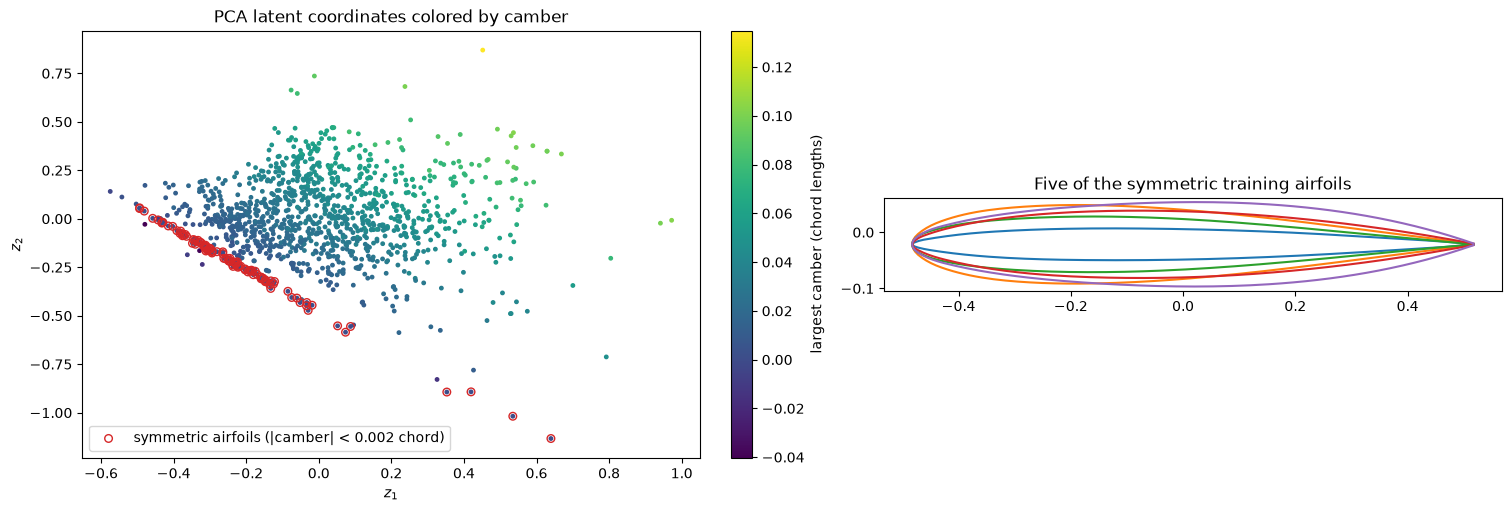

In [5]:
corr_pca = np.corrcoef(Z_pca.T)
corr_sp = np.corrcoef(Z_sp.T)
print(f"PCA: largest |correlation| between two different latent coordinates {np.abs(corr_pca - np.eye(20)).max():.1e}")
print(f"Sparse PCA: largest |correlation| between two different latent coordinates {np.abs(corr_sp - np.eye(12)).max():.2f}")
print(f"Sparse PCA: largest |cosine| between two different components {np.abs((W_sp @ W_sp.T) - np.eye(12)).max():.2f}")


def camber_and_thickness(airfoil):
    """Largest camber (signed) and largest thickness of one airfoil, both in chord lengths."""
    xy = make_airfoil(airfoil) + coordinate_means
    upper, lower = xy[:97][::-1], xy[96:]                      # both surfaces from leading to trailing edge
    x = np.linspace(0.02, 0.98, 60)
    y_upper = np.interp(x, upper[:, 0], upper[:, 1])
    y_lower = np.interp(x, lower[:, 0], lower[:, 1])
    camber_line = (y_upper + y_lower) / 2
    return camber_line[np.argmax(np.abs(camber_line))], np.max(y_upper - y_lower)


camber, thickness = np.array([camber_and_thickness(a) for a in X_train]).T
print(f"\nfraction of training airfoils with |camber| < 0.002 chord (symmetric): {np.mean(np.abs(camber) < 0.002):.1%}")
print(f"fraction with camber below -0.005 chord (cambered the wrong way): {np.mean(camber < -0.005):.1%}")
design = np.column_stack([Z_pca[:, :2], np.ones(len(Z_pca))])
coefficients = np.linalg.lstsq(design, camber, rcond=None)[0]
fitted_camber = design @ coefficients
print(f"R^2 of camber as a linear function of z1 and z2: {1 - np.var(camber - fitted_camber) / np.var(camber):.3f}")

# PCA samples from the independent normal distribution: how many fall on the far side of the edge?
rng = np.random.default_rng(1)
Z_draw = Z_pca.mean(axis=0) + Z_pca.std(axis=0) * rng.standard_normal((5000, 20))
draw_camber = np.column_stack([Z_draw[:, :2], np.ones(5000)]) @ coefficients
print(f"predicted camber below -0.005 chord: training airfoils {np.mean(fitted_camber < -0.005):.1%}, "
      f"independent normal samples {np.mean(draw_camber < -0.005):.1%}")

symmetric = np.flatnonzero(np.abs(camber) < 0.002)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), layout='constrained')
image = axes[0].scatter(Z_pca[:, 0], Z_pca[:, 1], c=camber, s=6, cmap='viridis')
axes[0].scatter(Z_pca[symmetric, 0], Z_pca[symmetric, 1], s=30, facecolors='none', edgecolors='C3',
                label='symmetric airfoils (|camber| < 0.002 chord)')
fig.colorbar(image, ax=axes[0], label='largest camber (chord lengths)')
axes[0].set_xlabel("$z_1$")
axes[0].set_ylabel("$z_2$")
axes[0].legend(loc='lower left')
axes[0].set_title("PCA latent coordinates colored by camber")
for i in np.random.default_rng(0).choice(symmetric, 5, replace=False):
    plot_airfoil(X_train[i], ax=axes[1])
axes[1].set_title("Five of the symmetric training airfoils")
plt.show()

**(a)** The PCA latent coordinates are $Z = (X - \mu) W^\top$, where the rows of $W$ are eigenvectors of the covariance matrix $\Sigma$. Their covariance is $W \Sigma W^\top = \operatorname{diag}(\lambda_1, \dots, \lambda_k)$, so they are uncorrelated (largest printed correlation $7 \times 10^{-16}$). The L1 penalty in Sparse PCA replaces the eigenvectors with components that each cover one part of the profile, and these components are not orthogonal (largest absolute cosine 0.45). Real airfoils change several parts together; for example, a thicker airfoil is thicker along most of its chord. So the coordinates of neighboring parts are correlated, up to 0.89.

**(b)** Rows 1 and 3 look like airfoils. Row 2 has wavy surfaces. Each Sparse PCA component moves one part of the profile, and independent sampling moves neighboring parts up and down at random, whereas in real airfoils they move together. For PCA, independent sampling works because the coordinates are uncorrelated: independent normal distributions already have the right mean and covariance. Sampling the Sparse PCA coordinates from a multivariate normal with the full $12 \times 12$ covariance restores the correlations and removes the waves.

**(c)** No. Uncorrelated means there is no linear trend between $z_1$ and $z_2$. Independent would mean that the distribution of $z_2$ does not depend on $z_1$, but the edge shows that the smallest possible $z_2$ depends on $z_1$. The figure above shows why. Camber is almost a linear function of $z_1$ and $z_2$ ($R^2 = 0.976$), and the symmetric airfoils (8.6% of the training set) lie along the edge. Only 0.6% of the airfoils have negative camber, so zero camber acts as a lower bound, and a lower bound on a linear function of $z$ is a straight line in the latent space. A normal distribution has no such bound: 3.6% of the independent normal samples have a predicted camber below $-0.005$ chord, against 0.2% of the training airfoils. These samples are airfoils cambered the wrong way.

A linear decomposition with a normal distribution can only match the mean and covariance of the data. Real design spaces have edges, clusters and curved boundaries that come from physical and design constraints, such as non-negative camber, positive thickness and no self-intersection. Generating realistic designs needs a model that can represent these, which is the subject of the generative models later in the course.

### Exercise 5: Filling in a gap in a scan

missing 51 points on the upper surface: RMS error on the missing points 0.0036 for this airfoil, median 0.0021 over all 306 held-out airfoils; condition number of the least-squares problem 5
missing the whole lower surface: RMS error on the missing points 0.0549 for this airfoil, median 0.0270 over all 306 held-out airfoils; condition number of the least-squares problem 217


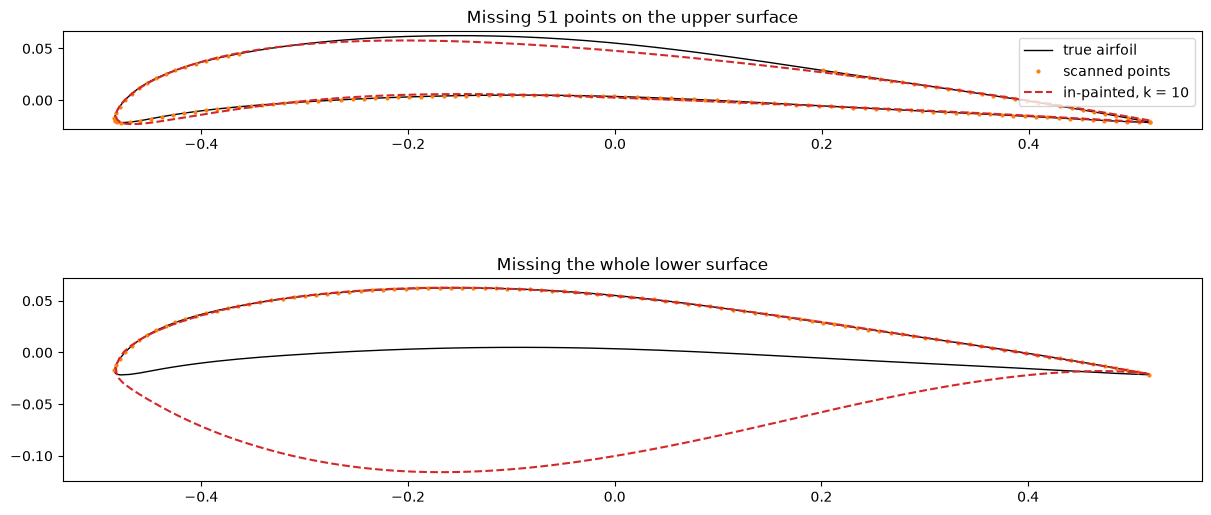

for comparison, projecting complete held-out airfoils onto 10 components: median RMS error 0.0007


In [6]:
def inpaint(observed_xy, observed_points, k):
    """Fit k PCA latent coordinates to the observed points only and return the full 384-vector reconstruction."""
    observed_coords = np.column_stack([2 * observed_points, 2 * observed_points + 1]).ravel()   # x, y of each point
    W = estimator.components_[:k, observed_coords]                 # rows of W restricted to the observed coordinates
    target = observed_xy.ravel() - estimator.mean_[observed_coords]
    z = np.linalg.lstsq(W.T, target, rcond=None)[0]                # one equation per observed coordinate, k unknowns
    return z @ estimator.components_[:k] + estimator.mean_


def gap_error(airfoil, missing_points, k=10):
    observed_points = np.setdiff1d(np.arange(192), missing_points)
    reconstruction = inpaint(make_airfoil(airfoil)[observed_points], observed_points, k)
    error = make_airfoil(reconstruction)[missing_points] - make_airfoil(airfoil)[missing_points]
    return reconstruction, np.sqrt(np.mean(error ** 2))


inpaint_id = 3
cases = {"51 points on the upper surface": np.arange(30, 81), "the whole lower surface": np.arange(97, 192)}
fig, axes = plt.subplots(2, 1, figsize=(12, 6), layout='constrained')
for ax, (name, missing_points) in zip(axes, cases.items()):
    observed_points = np.setdiff1d(np.arange(192), missing_points)
    reconstruction, error = gap_error(X_test[inpaint_id], missing_points)
    over_all = [gap_error(x, missing_points)[1] for x in X_test]
    observed_coords = np.column_stack([2 * observed_points, 2 * observed_points + 1]).ravel()
    condition = np.linalg.cond(estimator.components_[:10, observed_coords].T)
    print(f"missing {name}: RMS error on the missing points {error:.4f} for this airfoil, "
          f"median {np.median(over_all):.4f} over all 306 held-out airfoils; "
          f"condition number of the least-squares problem {condition:.0f}")
    observed_xy = make_airfoil(X_test[inpaint_id])[observed_points]
    plot_airfoil(X_test[inpaint_id], ax=ax, color='k', linewidth=1, label='true airfoil')
    ax.plot(observed_xy[:, 0], observed_xy[:, 1], '.', color='C1', markersize=4, label='scanned points')
    plot_airfoil(reconstruction, ax=ax, color='C3', linestyle='--', label='in-painted, k = 10')
    ax.set_title(f"Missing {name}")
axes[0].legend(loc='upper right')
plt.show()

full_projection = rms_error(X_test, reconstruct_pca(X_test, 10))
print(f"for comparison, projecting complete held-out airfoils onto 10 components: median RMS error {np.median(full_projection):.4f}")

**(a)** For held-out airfoil 3, the RMS error over the 51 missing points is 0.0036 chord. Over all 306 held-out airfoils the median is 0.0021, against 0.0007 for projecting complete airfoils onto the same ten components. In-painting works because the coordinates of an airfoil are strongly correlated: ten components explain over 99% of the variance, and each component's shape inside the gap is tied to its shape outside. The 141 observed points give 282 equations for 10 unknowns, so the latent coordinates are well determined, and the basis then fills in the gap. The basis acts as a prior learned from the training airfoils.

**(b)** With the lower surface hidden, the median error rises to 0.027, more than ten times worse. For airfoil 3 the filled-in lower surface lies far below the true one, even though the upper surface fits well. The upper surface does not determine the lower one: a thin airfoil with strong camber and a thicker airfoil with less camber can have nearly the same upper surface. Some combinations of latent coordinates hardly change the observed points, so the least-squares problem is badly conditioned (condition number 217, against 5 for the gap on the upper surface), and those combinations can take large values. Filling a gap with data on both sides is interpolation; filling a whole missing surface is extrapolation.

**(c)** No. Many airfoils fit the observed points almost equally well and differ mainly inside the gap, and least squares returns one of them. For a tolerance check you would want a distribution over possible fills, for example a band around the profile or the probability that the deviation exceeds the tolerance. That lets you tell "within tolerance" apart from "not enough data, rescan". It requires a probabilistic model of the latent coordinates, like the normal distributions in Exercise 4: conditioning that model on the observed points gives a mean fill and its uncertainty. The generative models later in the course can sample many plausible fills.